# Loan Approval — Exploratory Data Analysis

**Purpose of this notebook:** explore the raw dataset, understand its structure, identify data quality issues, and *justify every preprocessing decision* that is encoded in `train.py`.

This notebook does **not** train any model. It is the analytical foundation, not the source of truth. `train.py` is.

**Contents:**
1. Setup
2. Data loading & overview
3. Target variable analysis (class imbalance)
4. Missing value analysis
5. Numeric feature distributions
6. Categorical feature distributions
7. Feature vs target relationships
8. Correlation analysis
9. Feature engineering motivation
10. Preprocessing decision summary

## 1. Setup

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluate import missing_values_table

DATA_FILE = project_root / "data" / "Loan_Prediction_Dataset.csv"

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

## 2. Data Loading & Overview

In [2]:
df = pd.read_csv(DATA_FILE)
df.drop(columns=['Loan_ID'], inplace=True)   # identifier — not a feature
print(f'Shape: {df.shape}')
df.head()

Shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**Observations from `.describe()`:**
- `ApplicantIncome`: mean 5 403, max 81 000 — extreme right skew. Log transform needed.
- `CoapplicantIncome`: 25th percentile is 0 — many applicants have no co-applicant.
- `LoanAmount`: mean 146k, max 700k — also right-skewed.
- `Loan_Amount_Term`: 75th percentile equals median (360 months = 30 years) — heavily concentrated at one value.
- `Credit_History`: binary (0/1), mean 0.84 → 84% have good credit history.

## 3. Target Variable Analysis — Class Imbalance

             Count  Percentage (%)
Loan_Status                       
Y              422            68.7
N              192            31.3


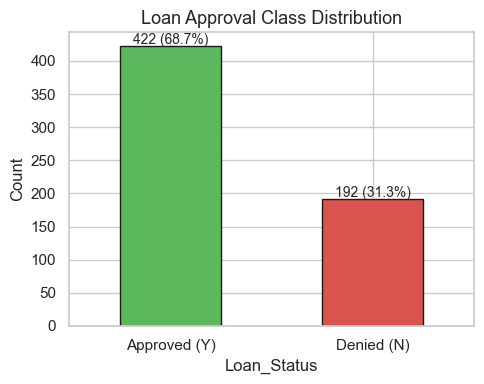

In [5]:
counts = df['Loan_Status'].value_counts()
pcts   = df['Loan_Status'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Count': counts, 'Percentage (%)': pcts}))

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#5cb85c', '#d9534f']
counts.plot(kind='bar', ax=ax, color=colors, edgecolor='k', width=0.5)
ax.set_title('Loan Approval Class Distribution', fontsize=13)
ax.set_xticklabels(['Approved (Y)', 'Denied (N)'], rotation=0)
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 3, f'{v} ({pcts.iloc[i]}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Finding:** ~69% approval rate — mild class imbalance.

**Implications for `train.py`:**
1. **Use `class_weight='balanced'`** on all classifiers so the minority class (Denied) is not drowned out.
2. **Use stratified train/test split** (`stratify=y`) to preserve the 69/31 ratio in both sets.
3. **Report AUC-ROC and macro-F1, not accuracy.** A model that always predicts 'Approved' gets 69% accuracy — that's our ceiling for a useless model, not a floor for a good one.

## 4. Missing Value Analysis

In [6]:
print(missing_values_table(df))

                  Missing Values  % of Total
Credit_History                50         8.1
Self_Employed                 32         5.2
LoanAmount                    22         3.6
Dependents                    15         2.4
Loan_Amount_Term              14         2.3
Gender                        13         2.1
Married                        3         0.5


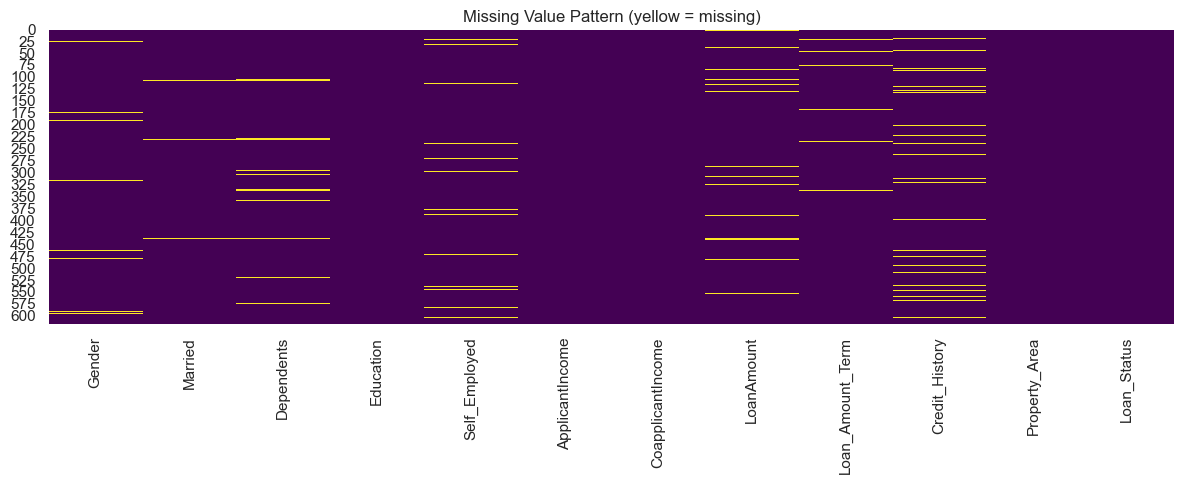

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Pattern (yellow = missing)')
plt.tight_layout()
plt.show()

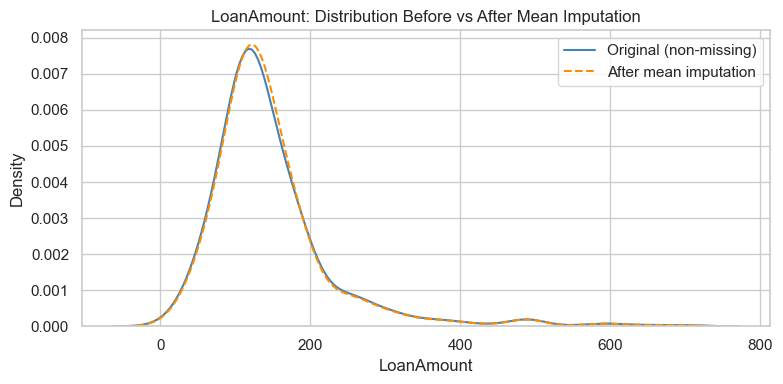

Mean:   146.4
Median: 128.0
Missing: 22 rows (3.6%)

Conclusion: mean ≈ median here and missing rate is low (3.7%).
Mean imputation causes only a minor spike at the mean — distribution shape is preserved.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
loan = df['LoanAmount'].dropna()
sns.kdeplot(loan, ax=ax, label='Original (non-missing)', color='steelblue')
sns.kdeplot(df['LoanAmount'].fillna(loan.mean()), ax=ax, label='After mean imputation', color='darkorange', linestyle='--')
ax.set_title('LoanAmount: Distribution Before vs After Mean Imputation')
ax.set_xlabel('LoanAmount')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean:   {loan.mean():.1f}')
print(f'Median: {loan.median():.1f}')
print(f'Missing: {df["LoanAmount"].isna().sum()} rows ({df["LoanAmount"].isna().mean():.1%})')
print('\nConclusion: mean ≈ median here and missing rate is low (3.7%).')
print('Mean imputation causes only a minor spike at the mean — distribution shape is preserved.')

**Imputation strategy decisions (justified here, implemented in `train.py` → `_impute()`):**

| Feature | Missing % | Strategy | Rationale |
|---|---|---|---|
| `Credit_History` | 8.1% | Mode (=1) | Binary feature; mode is always 1.0. **Known limitation:** this biases toward approval for 50 rows. The real-world fix would be to treat missing credit history as its own category. |
| `Self_Employed` | 4.9% | Mode (='No') | Categorical; majority class is 'No'. Low missing rate makes imputation low-risk. |
| `LoanAmount` | 3.7% | Mean | Continuous, low missing rate. Mean is a reasonable central estimate. |
| `Gender` | 2.1% | Mode (='Male') | Categorical; majority class is 'Male'. |
| `Loan_Amount_Term` | 2.3% | KNN (k=5) | Discrete valid terms (12, 36, 60…480 months). KNN picks a plausible neighbour value; mean would produce an impossible term. |
| `Dependents` | 2.4% | Mode (='0') | Categorical/ordinal; majority have 0 dependents. |
| `Married` | 0.5% | Mode (='Yes') | Categorical; negligible missing rate. |

## 5. Numeric Feature Distributions

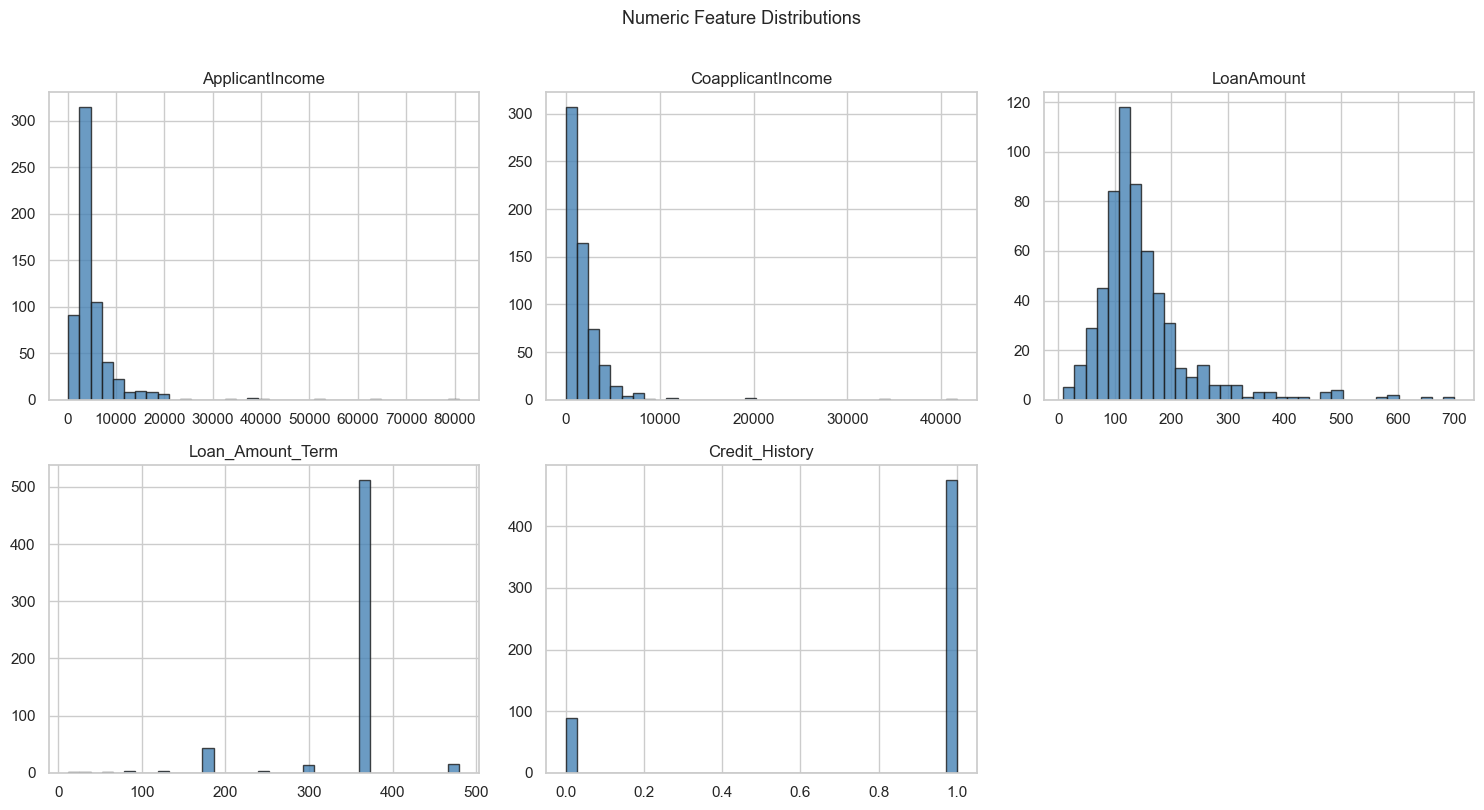

In [9]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].dropna().hist(ax=ax, bins=35, edgecolor='k', color='steelblue', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
axes.flat[-1].set_visible(False)   # hide unused subplot
plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Quantify skewness
skews = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].skew()
print('Skewness (|value| > 1 suggests significant right skew):')
print(skews.round(2))

Skewness (|value| > 1 suggests significant right skew):
ApplicantIncome      6.54
CoapplicantIncome    7.49
LoanAmount           2.68
dtype: float64


**Finding:** `ApplicantIncome` and `CoapplicantIncome` are heavily right-skewed (skewness >> 1). Log-transforming these will:
- Make distributions more Gaussian → benefits logistic regression
- Compress extreme outliers → reduces their outsized influence on distance-based anomaly detection
- Produce better tree splits by reducing the dominance of extreme values

## 6. Categorical Feature Distributions

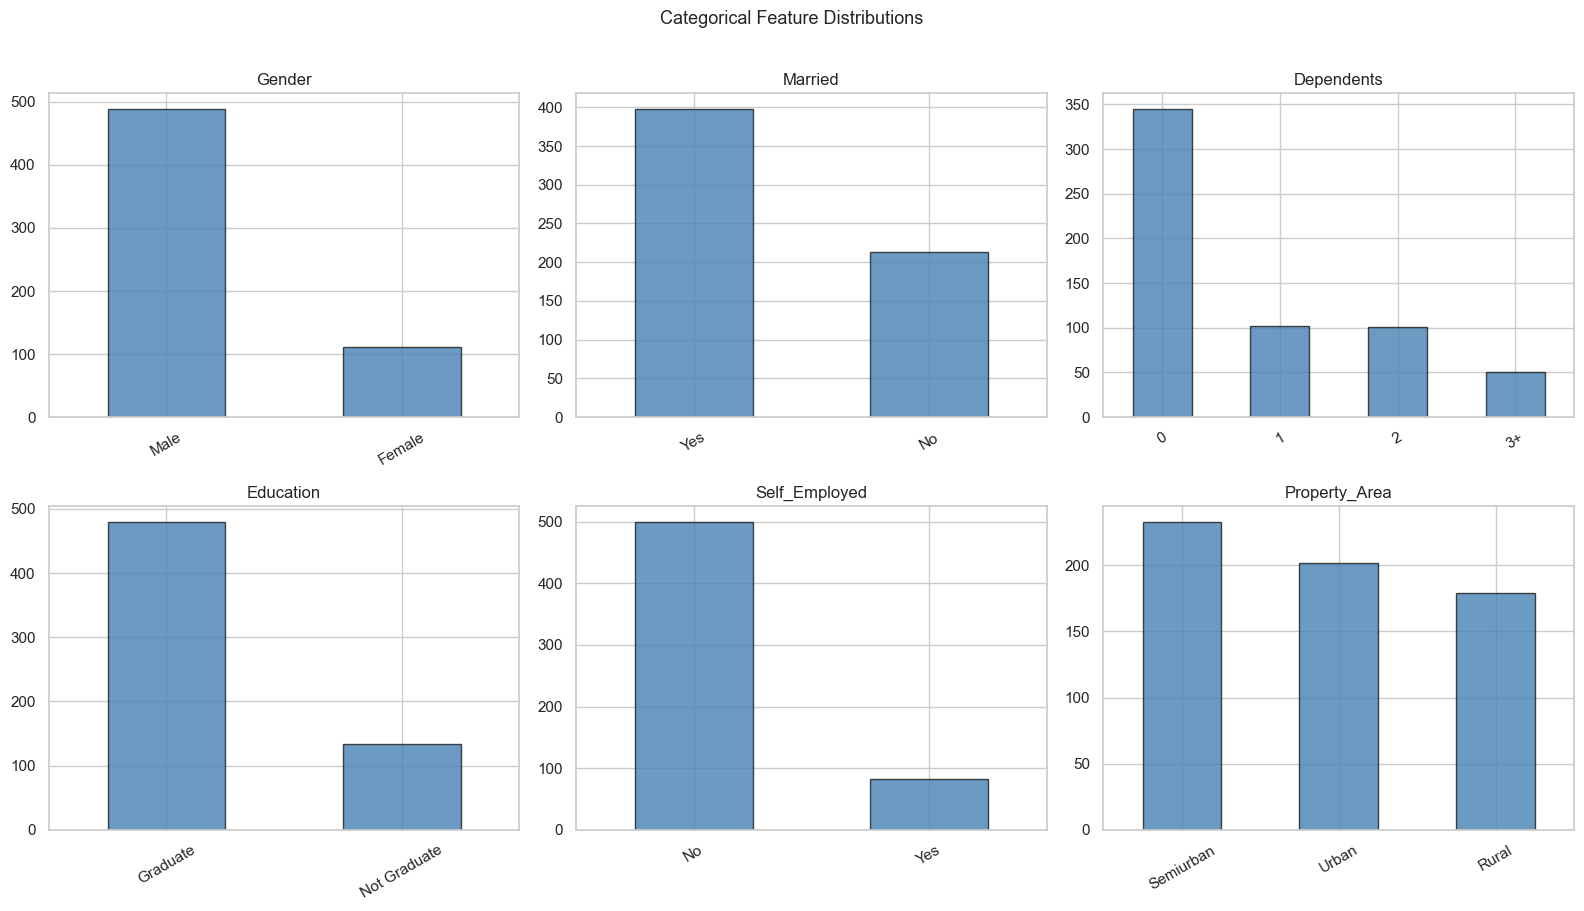

In [11]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='k', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Encoding decisions:**
- `Dependents` (0, 1, 2, 3+): treated as **ordinal** (mapped 3+→3, kept as integer). The order carries meaning: more dependents = higher household expenses.
- All others: **one-hot encoded with `drop_first=True`** to avoid the dummy variable trap (perfect multicollinearity when using an intercept term).

## 7. Feature vs Target Relationships

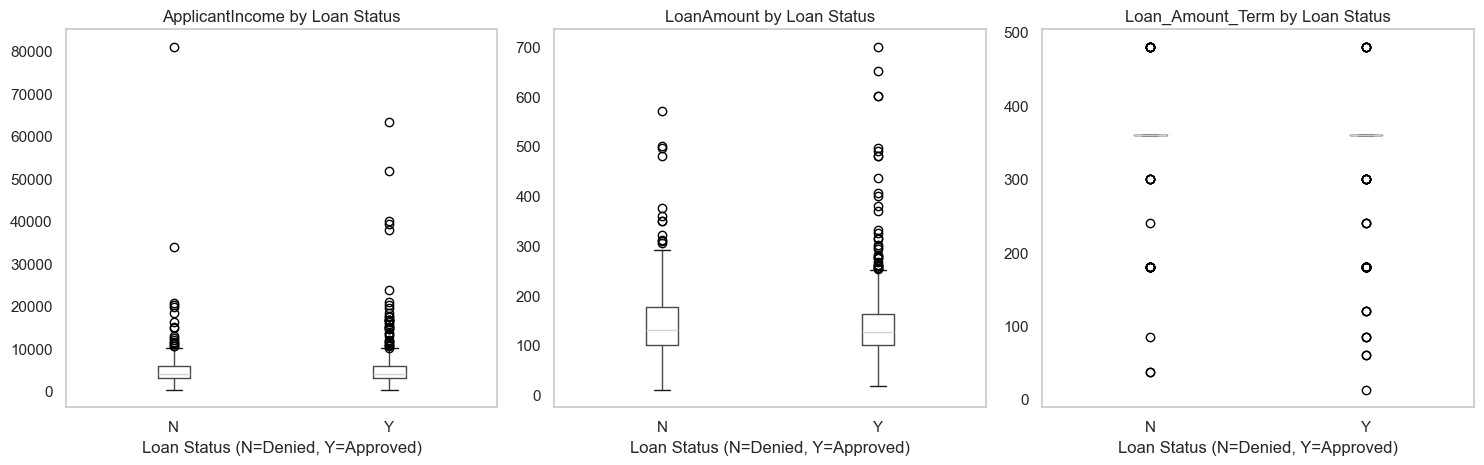

In [12]:
# Numeric features split by Loan_Status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term']):
    df.boxplot(column=col, by='Loan_Status', ax=ax, grid=False)
    ax.set_title(f'{col} by Loan Status')
    ax.set_xlabel('Loan Status (N=Denied, Y=Approved)')
plt.suptitle('')
plt.tight_layout()
plt.show()

Approval rate by Credit_History:
Loan_Status        N     Y
Credit_History            
0.0             92.1   7.9
1.0             20.4  79.6


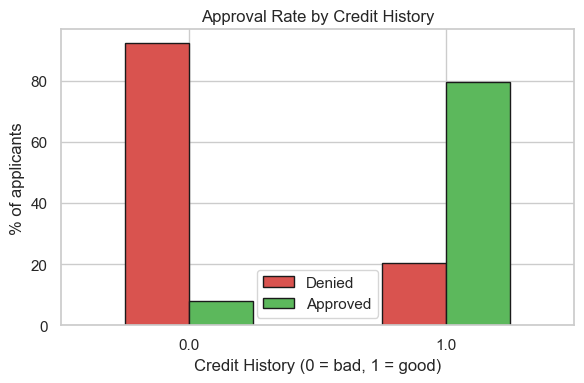

In [13]:
# Credit_History vs Loan_Status — the most important feature
ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index').mul(100).round(1)
print('Approval rate by Credit_History:')
print(ct)

ct.plot(kind='bar', figsize=(6, 4), color=['#d9534f', '#5cb85c'], edgecolor='k')
plt.title('Approval Rate by Credit History')
plt.xlabel('Credit History (0 = bad, 1 = good)')
plt.ylabel('% of applicants')
plt.xticks(rotation=0)
plt.legend(['Denied', 'Approved'])
plt.tight_layout()
plt.show()

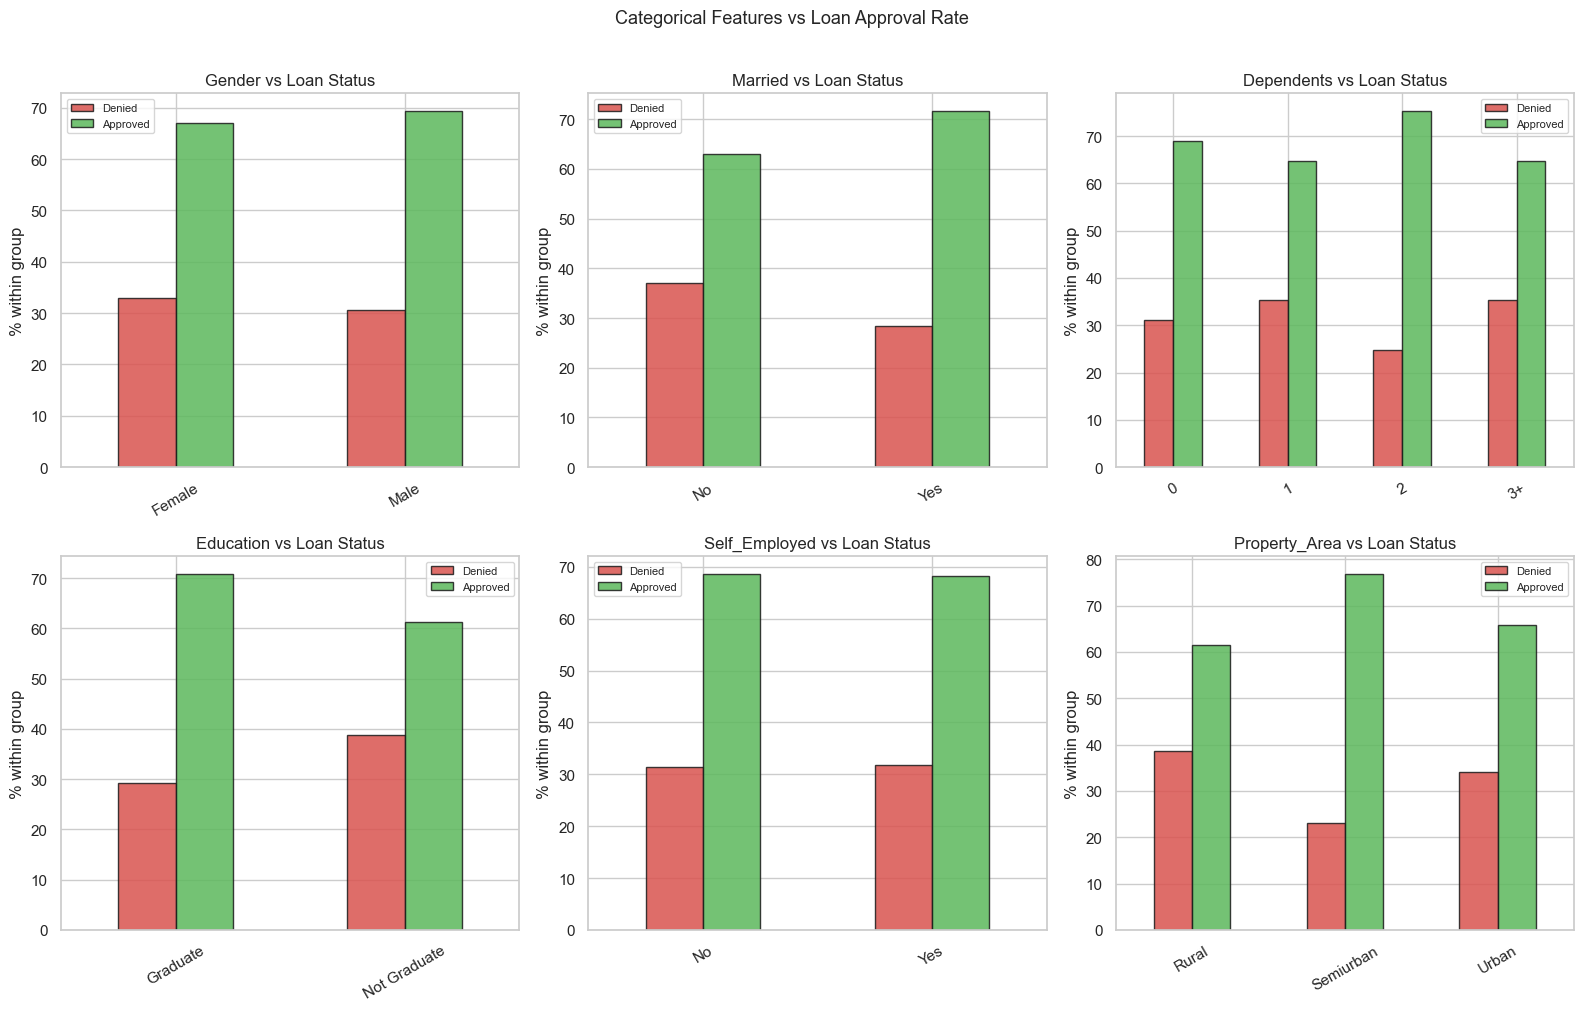

In [14]:
# Categorical features vs Loan_Status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index').mul(100)
    ct.plot(kind='bar', ax=ax, color=['#d9534f', '#5cb85c'], edgecolor='k', alpha=0.85)
    ax.set_title(f'{col} vs Loan Status')
    ax.set_ylabel('% within group')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Denied', 'Approved'], fontsize=8)
plt.suptitle('Categorical Features vs Loan Approval Rate', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Key findings:**
- **Credit_History** is the most discriminative feature by a wide margin: applicants with good credit (1) are approved ~80% of the time vs ~7% for bad credit (0).
- **Property_Area**: Semiurban has the highest approval rate.
- **Married**: Married applicants are approved at a slightly higher rate.
- **Income / LoanAmount**: medians are similar across approved/denied — raw income alone isn't a strong predictor; *relative* loan burden (loan-to-income ratio) will matter more.

## 8. Correlation Analysis

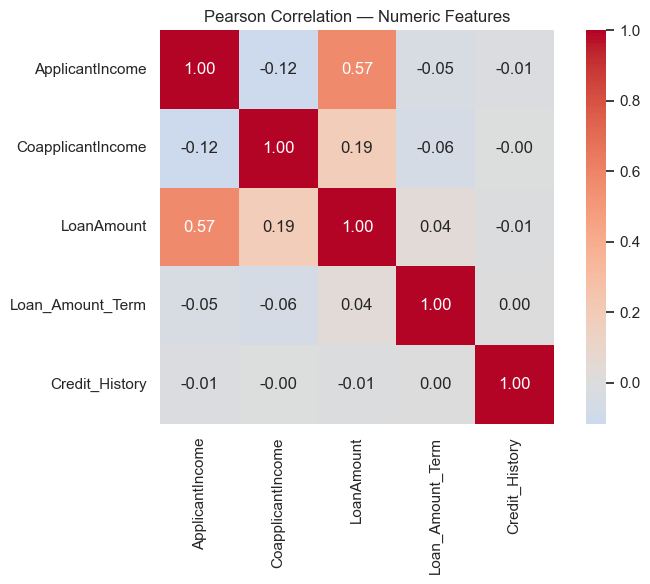

In [15]:
numeric_df = df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    numeric_df.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax, square=True,
)
ax.set_title('Pearson Correlation — Numeric Features')
plt.tight_layout()
plt.show()

**Findings:**
- `LoanAmount` and `ApplicantIncome` are positively correlated (r≈0.57) — higher earners borrow more.
- No severe multicollinearity among raw features.
- Note: the engineered features (`Total_Income`, `EMI`, `Loan_Income_Ratio`) will be correlated with their source columns — tree models handle this naturally; regularised linear models handle it via L2 penalty.

## 9. Feature Engineering Motivation

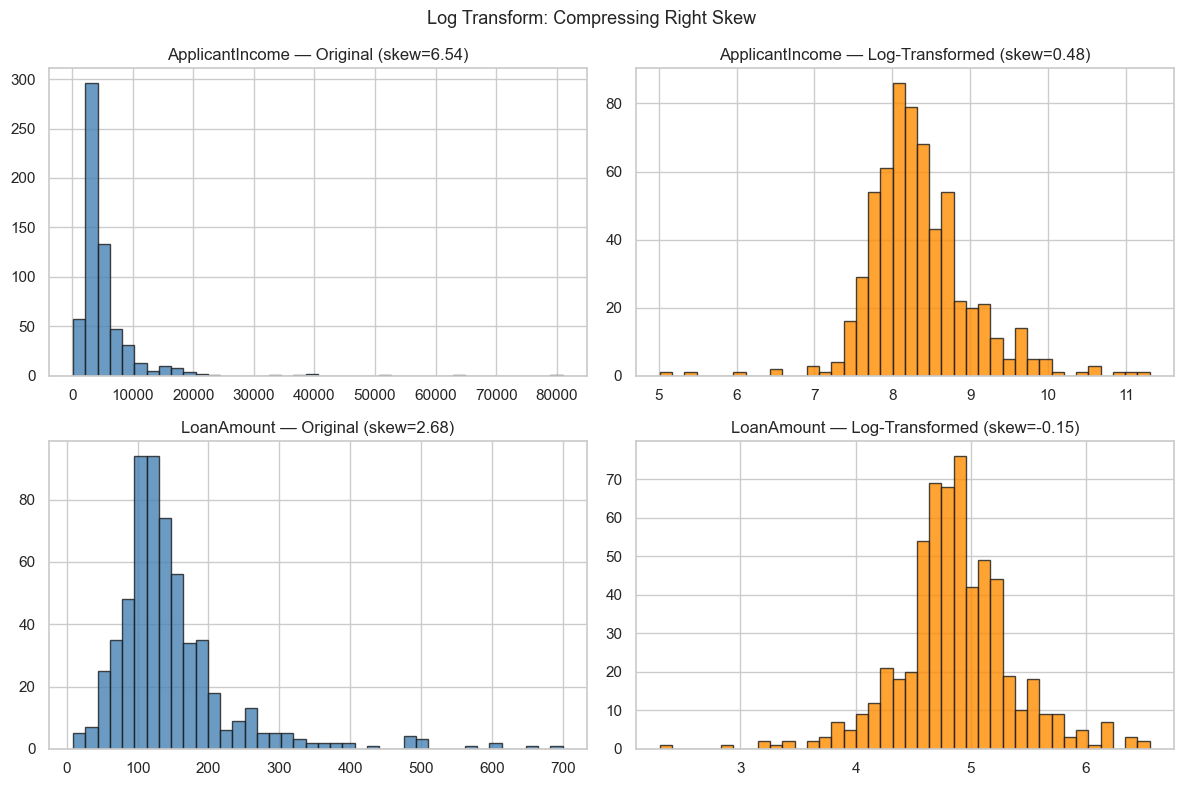

In [16]:
# Show the effect of log-transforming skewed features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(['ApplicantIncome', 'LoanAmount']):
    axes[i, 0].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='k', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Original (skew={df[col].skew():.2f})')

    log_vals = np.log1p(df[col].dropna())
    axes[i, 1].hist(log_vals, bins=40, color='darkorange', edgecolor='k', alpha=0.8)
    axes[i, 1].set_title(f'{col} — Log-Transformed (skew={log_vals.skew():.2f})')

plt.suptitle('Log Transform: Compressing Right Skew', fontsize=13)
plt.tight_layout()
plt.show()

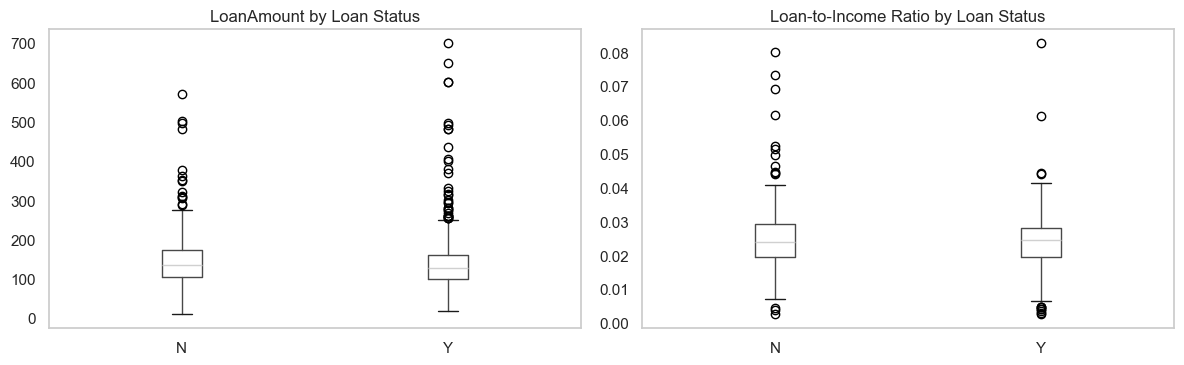

Mean Loan_Income_Ratio by status:
Loan_Status
N    0.025
Y    0.023
Name: Loan_Income_Ratio, dtype: float64


In [17]:
# Loan-to-Income Ratio is more predictive than raw LoanAmount
# because two applicants with the same loan amount have very different risk
# profiles if one earns 2× the other.

# Proxy: compute ratio on full dataset (imputing NaN for illustration only)
df_tmp = df.copy()
df_tmp['LoanAmount']  = df_tmp['LoanAmount'].fillna(df_tmp['LoanAmount'].mean())
df_tmp['Total_Income']      = df_tmp['ApplicantIncome'] + df_tmp['CoapplicantIncome']
df_tmp['Loan_Income_Ratio'] = df_tmp['LoanAmount'] / df_tmp['Total_Income']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes,
    ['LoanAmount', 'Loan_Income_Ratio'],
    ['LoanAmount by Loan Status', 'Loan-to-Income Ratio by Loan Status']
):
    df_tmp.boxplot(column=col, by='Loan_Status', ax=ax, grid=False)
    ax.set_title(title)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Mean Loan_Income_Ratio by status:')
print(df_tmp.groupby('Loan_Status')['Loan_Income_Ratio'].mean().round(3))

**Engineered features and their rationale:**

| Feature | Formula | Why |
|---|---|---|
| `Total_Income` | Applicant + CoApplicant | True household repayment capacity |
| `LoanAmount_log` | log(1 + LoanAmount) | Compress right skew |
| `TotalIncome_log` | log(1 + Total_Income) | Compress right skew |
| `EMI` | LoanAmount / Loan_Amount_Term | Monthly instalment proxy |
| `BalanceIncome` | Total_Income − EMI × 1000 | Disposable income after repayment |
| `Loan_Income_Ratio` | LoanAmount / Total_Income | Debt-to-income ratio — classic lending risk signal |

## 10. Preprocessing Decision Summary

Everything below is a decision — justified by the analysis above — and is implemented in `train.py`.

### Data cleaning
- Drop `Loan_ID` (identifier, not a feature)
- Impute per the table in Section 4 → `_impute()`

### Encoding
- `Dependents`: ordinal mapping (0/1/2/3+→3)
- All other categoricals: one-hot with `drop_first=True`
→ `_encode()`

### Feature engineering
- 6 derived features (see Section 9 table) → `_engineer()`

### Scaling
- StandardScaler on continuous numeric columns only
- Applied **after** feature engineering, **before** anomaly detection
- Fit on training data only → `_scale()`

### Train/test split
- 80/20, stratified on `Loan_Status` (preserves 69/31 class ratio)
- `random_state=42` for reproducibility

### Class imbalance
- `class_weight='balanced'` on all classifiers
- Primary metric: AUC-ROC + macro-F1 (not accuracy)

### Anomaly detection
- Run on scaled training data only (test set is never filtered)
- Ensemble of 3 detectors; row removed only if ≥2 agree